# Examples of mapping real world fix-route buses into the simulation

In [1]:
from utils.util import *
from clients.METSRClient import METSRClient

# Example 1: Run the transit route in the simulation (open loop)

In [2]:
with open("input/Birmingham_transit_data/stop_to_link_mapping.json", "r") as f:
      stop2link = json.load(f)

for i in range(1):
      print(stop2link[list(stop2link.keys())[i]])

{'stops': [[-86.874491, 33.49398], [-86.859491, 33.500061], [-86.845215, 33.499688], [-86.841138, 33.498493], [-86.839618, 33.493104], [-86.834799, 33.490707], [-86.827743, 33.494075], [-86.820784, 33.497392], [-86.810902, 33.503497], [-86.806807, 33.505514], [-86.804913, 33.507946], [-86.806948, 33.510819], [-86.808124, 33.5127], [-86.786178, 33.52359], [-86.776278, 33.528352], [-86.771852, 33.530353], [-86.760746, 33.535633], [-86.750615, 33.541226]], 'stop_zones': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18], 'assigned_links': ['-183945766#2', '7766854#18', '870847372#0', '183945767#4', '7745224', '-7749206#9', '-608662037#14', '-608662037#1', '-422477569', '746300584#9', '771558766#6', '-751530242#7', '259309286#1', '165419545#0', '-165419545#17', '165419545#23', '-736505309#3', '-7737602#2'], 'route_links': ['203055723#4', '7778958#1', '203055723#4', '-7737602#2', '-7737602#1', '7737602#2', '-7737602#2', '203055723#4', '-7778958#1', '203055723#2', '203055723#1',

In [3]:
from utils.util import *
from clients.METSRClient import METSRClient

In [4]:
config = read_run_config("configs/run_interactive_Birmingham.json")

In [5]:
sim_dirs = prepare_sim_dirs(config)
run_simulation_in_docker(config)

print(sim_dirs)


No port number specified, find available ports for simulation instances
['output/Birmingham_20250709_224158_seed_42']


In [6]:
sim_client = METSRClient(host="localhost", sim_folder=sim_dirs[0], port = config.ports[0], verbose=False, timeout=300) 

Attempt to connect to ws://localhost:59694 failed. Waiting for 10 seconds before trying again... (5 attempts remaining)
Connection established!


In [7]:
# add the first bus route to the simulation
for route_name, route_info in stop2link.items():
    print(f"Route Name: {route_name}")
    sim_client.add_bus_route(routeName=route_name, zone = route_info["stop_zones"], road= route_info["assigned_links"])
    break

Route Name: 100_36_1


In [8]:
route_info = sim_client.query_bus_route("100_36_1")
route_info

{'DATA': [{'stopRoads': ['-183945766#2',
    '7766854#18',
    '870847372#0',
    '183945767#4',
    '7745224',
    '-7749206#9',
    '-608662037#14',
    '-608662037#1',
    '-422477569',
    '746300584#9',
    '771558766#6',
    '-751530242#7',
    '259309286#1',
    '165419545#0',
    '-165419545#17',
    '165419545#23',
    '-736505309#3',
    '-7737602#2'],
   'routeID': 0,
   'stopZones': [1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18],
   'routeName': '100_36_1'}],
 'TYPE': 'ANS_getBusRoute'}

In [9]:
# add a bus run to the first route
for route_name, route_info in stop2link.items():
    print(f"Route Name: {route_name}")
    print(sim_client.add_bus_run(routeName = route_name, departTime = [0] * len(route_info['stop_zones'])))
    break

Route Name: 100_36_1
{'CODE': 'OK', 'DATA': [{'STATUS': 'OK', 'routeName': '100_36_1'}], 'TYPE': 'CTRL_addBusRun'}


In [10]:
sim_client.tick(600)

In [11]:
bus_info = sim_client.query_route_bus("100_36_1")
bus_info

{'DATA': [{'routeID': 0, 'busIDs': [1000], 'routeName': '100_36_1'}],
 'TYPE': 'ANS_getBusWithRoute'}

In [12]:
sim_client.query_bus(1000)

{'DATA': [{'battery_state': 207.41255936862174,
   'route': '100_36_1',
   'current_stop': -1,
   'pass_num': 0,
   'ID': 1000}],
 'TYPE': 'ANS_bus'}

In [13]:
# collect the vehicle path
xs, ys = [], []

# Run a 60 min simulation, record the trajectory every 1s
for i in range(3600):
      query_res = sim_client.query_vehicle(1000)
      xs.append(query_res['DATA'][0]['x'])
      ys.append(query_res['DATA'][0]['y'])

      sim_client.tick(5)

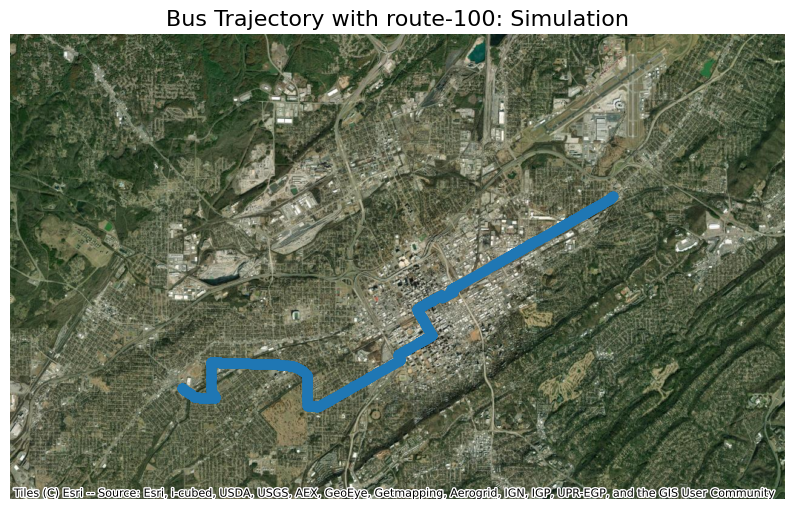

In [14]:
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd

# Force the default size for all figures in this script
plt.rcParams['figure.figsize'] = (10, 10)
# plt.rcParams['figure.dpi']     = 100

# Example 1: Collect and visualize the trajectory of one vehicle
fig, ax = plt.subplots()  
# (Because of rcParams above, this will be 10"×10" at 100 dpi.)

# add the NYC map
gdf = (
    gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(xs, ys),
        crs='EPSG:4326'
    )
    .to_crs(epsg=3857)
)
gdf.plot(ax=ax)
ax.set_title("Bus Trajectory with route-100: Simulation", fontsize= 16)

# Add the basemap without changing fig size
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, reset_extent=False)

ax.set_axis_off()

# If you save, this guarantees the output file is also 10"x10"
# fig.savefig("trajectory.png", bbox_inches='tight')
plt.show()


In [15]:
sim_client.terminate()

# Example 2: Bus run to simulation mapping (closed loop)

In [30]:
from utils.util import *
from clients.METSRClient import METSRClient

In [31]:
config = read_run_config("configs/run_interactive_Birmingham.json")

In [32]:
with open("input/Birmingham_transit_data/final_bus_runs_dictionary.json", "r") as f:
      busrun2trajectory = json.load(f)

for i in range(1):
      print(busrun2trajectory[list(busrun2trajectory.keys())[i]])

{'route_variant': '1_2_1', 'visited_stop': [321, 322, 323, 324, 325, 326, 327, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 341, 344, 345, 349, 355, 356, 357, 360, 363, 364, 365, 370, 371, 374, 376, 377, 378, 379, 380], 'visited_road': ['-39992256', '769551523#10', '7765425#8', '119882420#6', '260003377', '259324658#5', '259324658#7', '260003379#3', '846366626#15', '846366626#15', '259323201#0', '259323201#2', '259323201#5', '259323201#11', '259323201#19', '259323201#20', '7759916#0', '7759916#2', '7759916#7', '7759916#25', '7759916#25', '7759916#43', '-313631565#19', '-313631565#13', '-313631565#6', '-313631567#5', '-774607064#6', '870847367#1', '-870847369#3', '-7783711#5', '183944547#5', '-7779373#5', '48688394#9', '-138812693#8', '1175015162#1', '872881113#1', '259308438#2'], 'path': [{'from_stop_index': 0, 'to_stop_index': 1, 'path_details': [{'linkID': '-39992256', 'distance': 74.790241342072, 'offset': 0.0}, {'linkID': '-39992256', 'distance': 0, 'offset': 22.568948}, 

In [33]:
sim_dirs = prepare_sim_dirs(config)
run_simulation_in_docker(config)

print(sim_dirs)

No port number specified, find available ports for simulation instances
['output/Birmingham_20250711_030924_seed_42']


In [34]:
sim_client = METSRClient(host="localhost", sim_folder=sim_dirs[0], port = config.ports[0], verbose=False, timeout=300) 

Attempt to connect to ws://localhost:60807 failed. Waiting for 10 seconds before trying again... (5 attempts remaining)
Connection established!


In [35]:
def format_path(raw_path):
      paths = []
      for segment in raw_path:
            current_link = None
            path = []
            for link in segment['path_details']:
                  if link['linkID'] != current_link:
                        path.append(link['linkID'])
            paths.append(path)

In [36]:
for bus_run_name, compressed_trajectory in busrun2trajectory.items():
    print(f"Bus Run Name: {bus_run_name}")
    print(f"Route Name: {compressed_trajectory['route_variant']}")

    zone_list = compressed_trajectory['visited_stop']
    road_list = compressed_trajectory['visited_road']
    path_list = compressed_trajectory['path']

    print(sim_client.add_bus_route(compressed_trajectory['route_variant'], zone_list, road_list, format_path(path_list)))
    break

Bus Run Name: 1_101_312
Route Name: 1_2_1
{'CODE': 'OK', 'DATA': [{'STATUS': 'OK', 'routeName': '1_2_1'}], 'TYPE': 'CTRL_addBusRoute'}


In [37]:
# add a bus run to the first route
for bus_run_name, compressed_trajectory in busrun2trajectory.items():
    print(f"Route Name: {compressed_trajectory['route_variant']}")
    print(sim_client.add_bus_run(routeName = [compressed_trajectory['route_variant'],compressed_trajectory['route_variant']], departTime = [[0] * len(zone_list), [0] * len(zone_list)]))
    break

Route Name: 1_2_1
{'CODE': 'OK', 'DATA': [{'STATUS': 'OK', 'routeName': '1_2_1'}, {'STATUS': 'OK', 'routeName': '1_2_1'}], 'TYPE': 'CTRL_addBusRun'}


In [38]:
bus_info = sim_client.query_route_bus("1_2_1")

# wait until a bus is assigned to the route (depending on whether there is a bus at the beginning of the stop)
while len(bus_info['DATA'][0]['busIDs']) == 0:
      sim_client.tick(120)
      bus_info = sim_client.query_route_bus("1_2_1")

In [40]:
bus_info

{'DATA': [{'routeID': 0, 'busIDs': [1028, 1029], 'routeName': '1_2_1'}],
 'TYPE': 'ANS_getBusWithRoute'}

In [41]:
sim_client.query_vehicle(1028)

{'DATA': [{'acc': 0.0,
   'bearing': 89.17831773534884,
   'x': -87.01006591212384,
   'y': 33.37571015055777,
   'ID': 1028,
   'state': 0,
   'v_type': 2,
   'speed': 0.0}],
 'TYPE': 'ANS_vehicle'}

In [ ]:
# collect the vehicle path
xs, ys = [], []

current_ind = 0
# Run a 60 min simulation, record the trajectory every 1s
for i in range(3600):
      # while compressed_trajectory['compressed_trajectory'][current_ind+1]['time_offset'] < i:
      #       current_ind += 1
      # link = compressed_trajectory['compressed_trajectory'][current_ind]['linkID']
      # distance = compressed_trajectory['compressed_trajectory'][current_ind]['distance_to_next_link'] * (i - compressed_trajectory['compressed_trajectory'][current_ind]['time_offset'])/(compressed_trajectory['compressed_trajectory'][current_ind + 1]['time_offset'] - compressed_trajectory['compressed_trajectory'][current_ind]['time_offset'])
      # sim_client.teleport_trace_replay_vehicle(1036, link , 0, distance)
      query_res = sim_client.query_vehicle(1028)
      xs.append(query_res['DATA'][0]['x'])
      ys.append(query_res['DATA'][0]['y'])

      sim_client.tick(5)

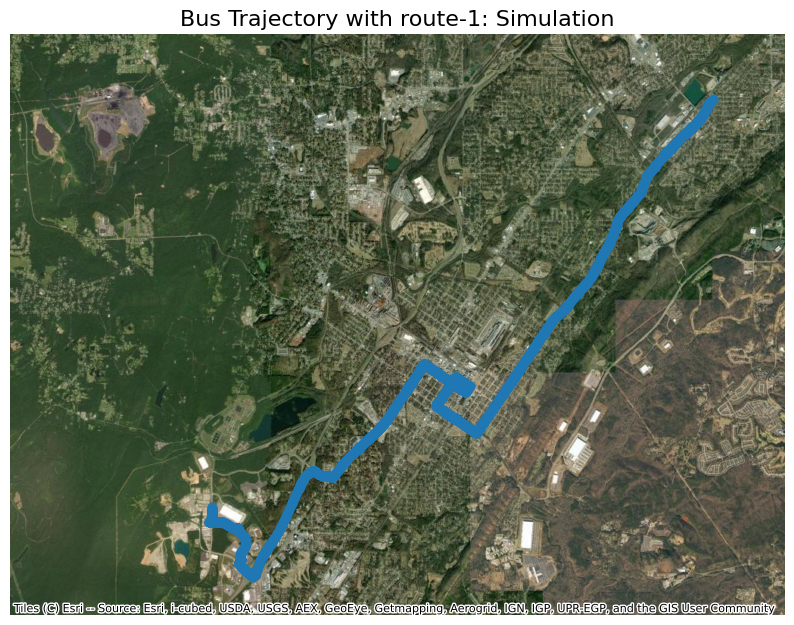

In [15]:
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd

# Force the default size for all figures in this script
plt.rcParams['figure.figsize'] = (10, 10)
# plt.rcParams['figure.dpi']     = 100

# Example 1: Collect and visualize the trajectory of one vehicle
fig, ax = plt.subplots()  
# (Because of rcParams above, this will be 10"×10" at 100 dpi.)

# add the NYC map
gdf = (
    gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(xs, ys),
        crs='EPSG:4326'
    )
    .to_crs(epsg=3857)
)
gdf.plot(ax=ax)
ax.set_title("Bus Trajectory with route-1: Simulation", fontsize= 16)

# Add the basemap without changing fig size
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, reset_extent=False)

ax.set_axis_off()

# If you save, this guarantees the output file is also 10"x10"
# fig.savefig("trajectory2.png", bbox_inches='tight')
plt.show()


In [20]:
sim_client.terminate()